# Lab 4: Getting Started with Image Processing Using scikit-image

This notebook implements Tasks 0-6 from the lab specification. It is self-contained: if
`images/coins.jpg` and `images/astronaut.jpg` do not exist, the setup cell creates them from
the standard images distributed with scikit-image.

## Task 0 - Software setup

Install the packages from the repository root with `pip install -r requirements.txt`.

In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage import data, io
from skimage.color import rgb2gray, gray2rgb
from skimage.transform import rescale, resize
from skimage.feature import match_template
from scipy.signal import correlate2d

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["image.cmap"] = "gray"

# This works both from the repository root and from notebooks/.
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

coins_path = IMAGE_DIR / "coins.jpg"
astronaut_path = IMAGE_DIR / "astronaut.jpg"
if not coins_path.exists():
    io.imsave(coins_path, gray2rgb(data.coins()))
if not astronaut_path.exists():
    io.imsave(astronaut_path, data.astronaut())

print(f"scikit-image version: {skimage.__version__}")
print(f"Images: {IMAGE_DIR.resolve()}")

scikit-image version: 0.26.0
Images: C:\Files\Learn\LTU\Programming for Machine Learning D0036E 17562 HT2026\Labs\Lab 4\lab-4-image-processing-scikit-image\images


## Task 1 - Load and visualize images

For each image we report shape, dtype, and the intensity at pixel `[1, 100, 1]`, then
display the image. Both JPEG files are RGB images, so the third index selects the green channel.

coins.jpg: shape=(303, 384, 3), dtype=uint8, pixel[1,100,1]=134
astronaut.jpg: shape=(512, 512, 3), dtype=uint8, pixel[1,100,1]=175


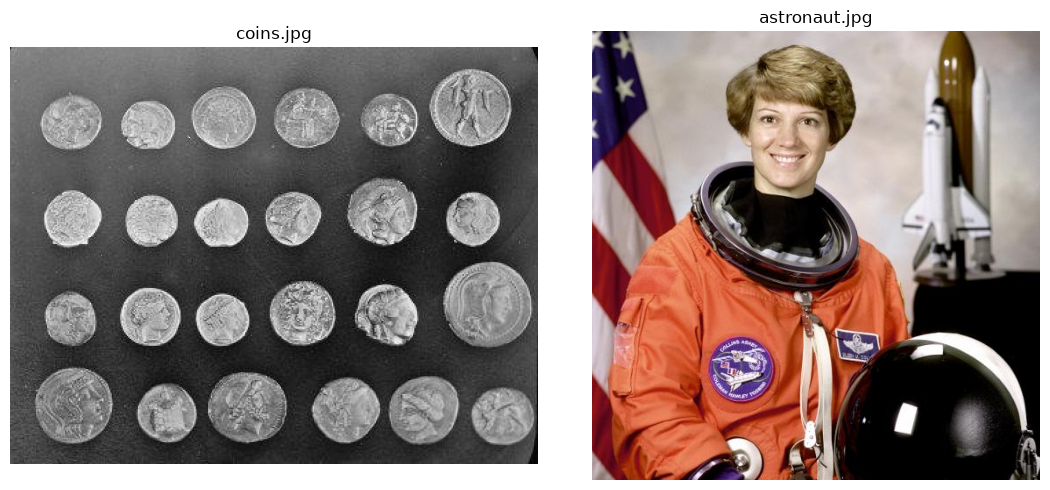

In [2]:
coins = io.imread(coins_path)
astronaut = io.imread(astronaut_path)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, image, name in zip(axes, [coins, astronaut], ["coins.jpg", "astronaut.jpg"]):
    print(f"{name}: shape={image.shape}, dtype={image.dtype}, pixel[1,100,1]={image[1,100,1]}")
    ax.imshow(image)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Task 2 - Color-space conversion

`rgb2gray` removes the three-channel RGB dimension by computing one luminance value per
pixel. Consequently `(height, width, 3)` becomes `(height, width)`. The input JPEG arrays
use `uint8` values from 0 to 255, while `rgb2gray` returns floating-point values in [0, 1].

coins    : (303, 384, 3), uint8 -> (303, 384), float64; range [0.000, 1.000]
astronaut: (512, 512, 3), uint8 -> (512, 512), float64; range [0.000, 1.000]


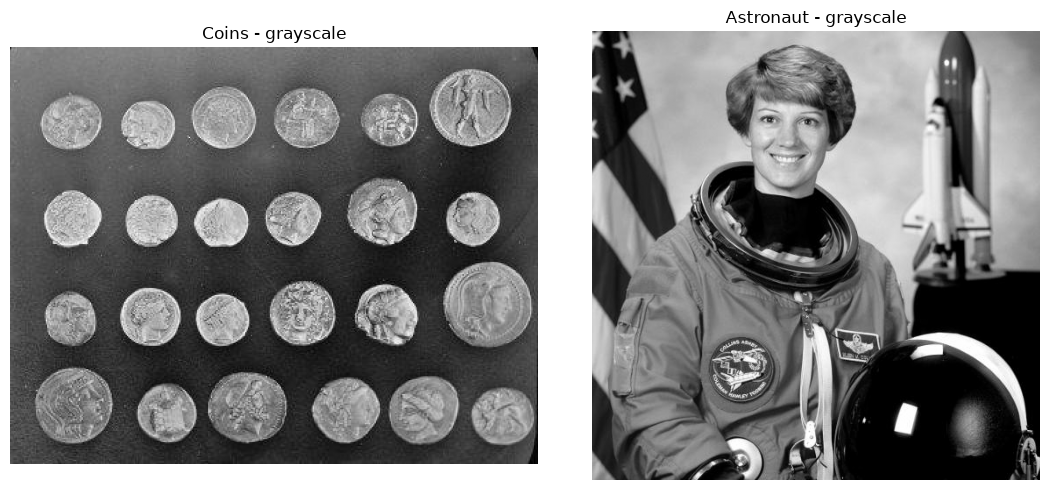

In [3]:
coins_gray = rgb2gray(coins)
astronaut_gray = rgb2gray(astronaut)

for name, original, grayscale in [
    ("coins", coins, coins_gray),
    ("astronaut", astronaut, astronaut_gray),
]:
    print(f"{name:9s}: {original.shape}, {original.dtype} -> {grayscale.shape}, {grayscale.dtype}; "
          f"range [{grayscale.min():.3f}, {grayscale.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(coins_gray, cmap="gray")
axes[0].set_title("Coins - grayscale")
axes[1].imshow(astronaut_gray, cmap="gray")
axes[1].set_title("Astronaut - grayscale")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## Task 3 - Image rescale and resize

`resize` targets an exact output height and width; here the astronaut is resized to 300 x 200.
`rescale` instead multiplies both spatial dimensions by a factor, preserving aspect ratio.
Anti-aliasing reduces jagged edges and moire when downsampling.

Original: (512, 512, 3)
Resized to chosen dimensions: (300, 200, 3)
Rescaled by 0.75: (384, 384, 3)
Rescaled by 0.5: (256, 256, 3)
Rescaled by 0.25: (128, 128, 3)


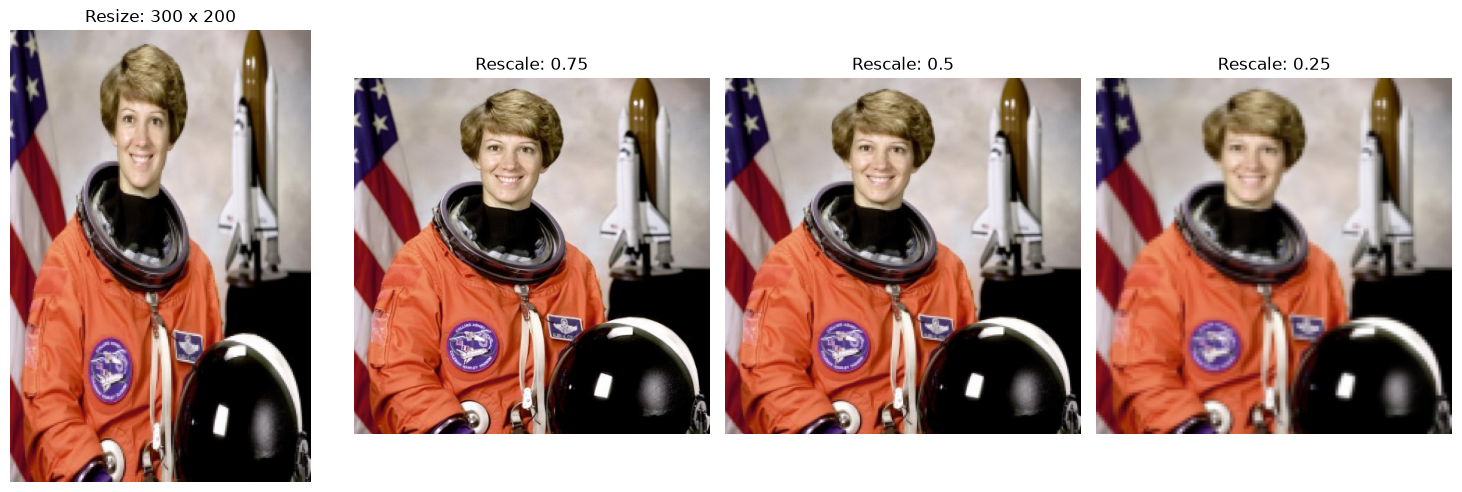

In [4]:
astronaut_resized = resize(astronaut, (300, 200), anti_aliasing=True)
scale_factors = [0.75, 0.5, 0.25]
astronaut_rescaled = {
    factor: rescale(astronaut, factor, channel_axis=-1, anti_aliasing=True)
    for factor in scale_factors
}

print(f"Original: {astronaut.shape}")
print(f"Resized to chosen dimensions: {astronaut_resized.shape}")
for factor, image in astronaut_rescaled.items():
    print(f"Rescaled by {factor}: {image.shape}")

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(astronaut_resized)
axes[0].set_title("Resize: 300 x 200")
for ax, (factor, image) in zip(axes[1:], astronaut_rescaled.items()):
    ax.imshow(image)
    ax.set_title(f"Rescale: {factor}")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## Task 4 - Image thresholding

The grayscale image is `float64`, so its intensities are in [0, 1]. Inspection of the histogram
shows a useful separation near **t = 0.42**. Following the lab's suggested expression,
`coins_gray < t` marks darker pixels as `True`. The result is Boolean; reversing the comparison
would instead make bright coin regions white.

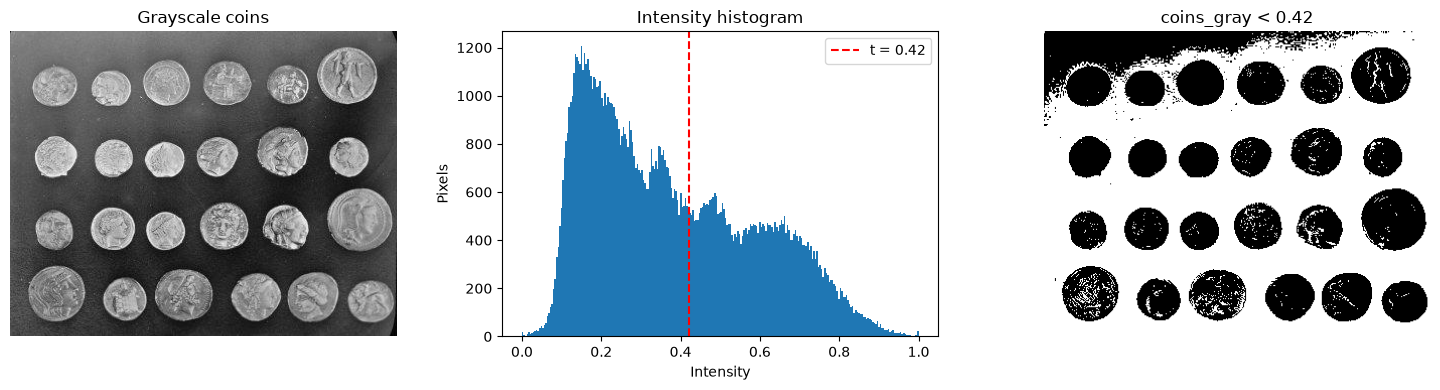

grayscale dtype=float64; binary dtype=bool


In [5]:
t = 0.42
binary = coins_gray < t

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(coins_gray, cmap="gray")
axes[0].set_title("Grayscale coins")
axes[0].axis("off")
axes[1].hist(coins_gray.ravel(), bins=256)
axes[1].axvline(t, color="red", linestyle="--", label=f"t = {t}")
axes[1].set(title="Intensity histogram", xlabel="Intensity", ylabel="Pixels")
axes[1].legend()
axes[2].imshow(binary, cmap="gray")
axes[2].set_title(f"coins_gray < {t}")
axes[2].axis("off")
plt.tight_layout()
plt.show()
print(f"grayscale dtype={coins_gray.dtype}; binary dtype={binary.dtype}")

## Task 5 - Template matching with scikit-image

The template is a crop containing one coin. `match_template` calculates normalized correlation
at every valid location. The brightest response (maximum correlation) is the best match, and the
red rectangle maps that response back onto the original image. Because the template itself comes
from the image, its source location should be the strongest match.

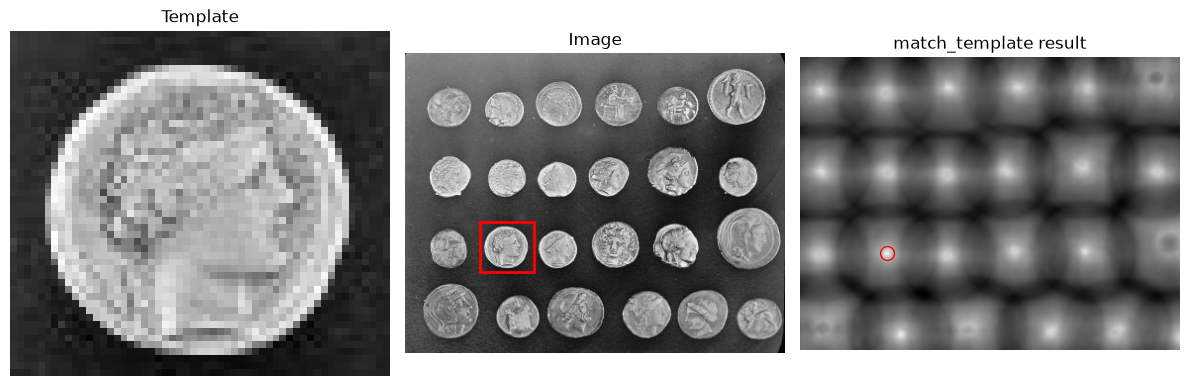

Best top-left position: (x=75, y=170); score=1.000000


In [6]:
template_image = data.coins()
coin = template_image[170:220, 75:130]
result = match_template(template_image, coin)
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

fig = plt.figure(figsize=(12, 4))
ax1 = plt.subplot(1, 3, 1)
ax2 = plt.subplot(1, 3, 2)
ax3 = plt.subplot(1, 3, 3)
ax1.imshow(coin)
ax1.set_title("Template")
ax2.imshow(template_image)
ax2.set_title("Image")
hcoin, wcoin = coin.shape
ax2.add_patch(plt.Rectangle((x, y), wcoin, hcoin, edgecolor="red", facecolor="none", linewidth=2))
ax3.imshow(result)
ax3.plot(x, y, "o", markeredgecolor="red", markerfacecolor="none", markersize=10)
ax3.set_title("match_template result")
for ax in (ax1, ax2, ax3): ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Best top-left position: (x={x}, y={y}); score={result[y, x]:.6f}")

## Task 6 - Own template-matching implementation

Below is an independent normalized cross-correlation (NCC) implementation. It does not call
`skimage.feature.match_template`. For every valid window, it compares the zero-mean template
with the zero-mean image patch and normalizes by their energies. Summed-area correlations make
the patch statistics efficient, while `correlate2d` computes the numerator. NCC is robust to
linear changes in brightness and produces scores near 1 for a strong positive match.

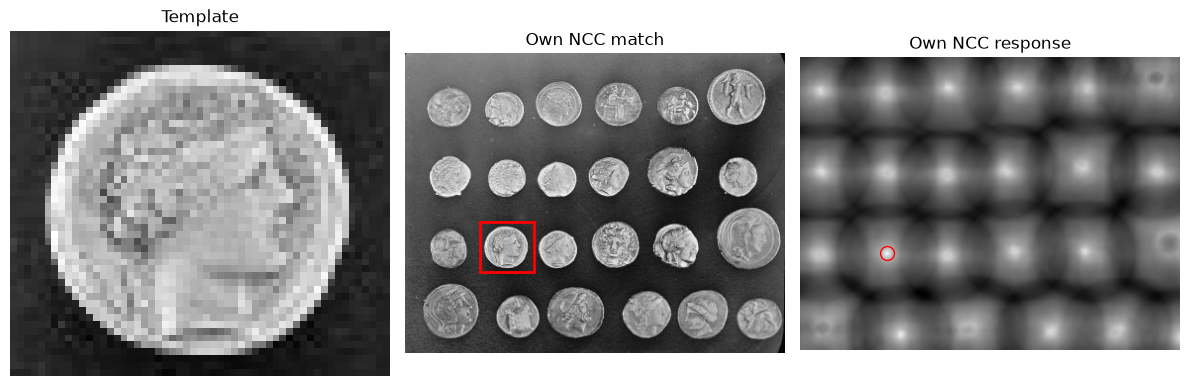

Own NCC position: (x=75, y=170); score=1.000000
scikit-image position: (x=75, y=170)
Same best location: True


In [7]:
def normalized_cross_correlation(image, template):
    """Return valid normalized cross-correlation for 2-D image and template arrays."""
    image = np.asarray(image, dtype=np.float64)
    template = np.asarray(template, dtype=np.float64)
    if image.ndim != 2 or template.ndim != 2:
        raise ValueError("image and template must both be 2-D")
    if any(t > i for t, i in zip(template.shape, image.shape)):
        raise ValueError("template must not be larger than image")

    h, w = template.shape
    n = h * w
    centered_template = template - template.mean()
    template_energy = np.sum(centered_template ** 2)

    # Since the template is zero-mean, correlating it with the raw image already
    # equals the sum of (patch - patch_mean) * centered_template.
    numerator = correlate2d(image, centered_template, mode="valid")
    kernel = np.ones((h, w), dtype=np.float64)
    patch_sum = correlate2d(image, kernel, mode="valid")
    patch_sum_sq = correlate2d(image ** 2, kernel, mode="valid")
    patch_energy = np.maximum(patch_sum_sq - (patch_sum ** 2) / n, 0)
    denominator = np.sqrt(patch_energy * template_energy)

    return np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 1e-12)


own_result = normalized_cross_correlation(template_image, coin)
own_y, own_x = np.unravel_index(np.argmax(own_result), own_result.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(coin)
axes[0].set_title("Template")
axes[1].imshow(template_image)
axes[1].add_patch(plt.Rectangle((own_x, own_y), wcoin, hcoin,
                                edgecolor="red", facecolor="none", linewidth=2))
axes[1].set_title("Own NCC match")
axes[2].imshow(own_result)
axes[2].plot(own_x, own_y, "o", markeredgecolor="red", markerfacecolor="none", markersize=10)
axes[2].set_title("Own NCC response")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Own NCC position: (x={own_x}, y={own_y}); score={own_result[own_y, own_x]:.6f}")
print(f"scikit-image position: (x={x}, y={y})")
print(f"Same best location: {(own_x, own_y) == (x, y)}")

## Conclusion

The notebook loaded and inspected RGB data, converted it to grayscale, changed spatial scale,
performed manual threshold segmentation, and located a template using both scikit-image and an
independent NCC implementation. The two template matchers are checked against each other by
comparing their best-match coordinates.